In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../Data/synthetic_it_support_tickets.csv")
df.head()

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,initial_message,agent_first_reply,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region
0,TCKT_000001,2024-01-31T05:14:27,CUST_00861,individual,email,data_export,account_access,low,resolved,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,Reset account credentials and confirmed succes...,36.53,0,very_negative,1,0,android,EU
1,TCKT_000002,2024-10-20T06:15:49,CUST_00770,individual,in_app,billing,security_concern,medium,closed_no_action,standard,I noticed a suspicious login on my account.,We take security very seriously. Our team is r...,Ticket closed without further action after no ...,238.32,0,neutral,3,0,web,NaN
2,TCKT_000003,2024-06-18T21:35:54,CUST_02559,small_business,chat,api_integration,bug,low,in_progress,standard,The api integration feature is not saving my c...,Thanks for reporting this bug. We will look in...,NaN,NaN,0,neutral,3,0,android,MEA
3,TCKT_000004,2025-12-25T15:59:52,CUST_03557,education,chat,analytics_dashboard,account_access,medium,in_progress,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,NaN,NaN,0,positive,5,1,android,LATAM
4,TCKT_000005,2023-08-27T16:08:33,CUST_09556,enterprise,phone_transcript,login_auth,billing_problem,low,resolved,gold,My invoice amount is incorrect compared to the...,Thanks for reaching out about the billing issu...,Adjusted the invoice and issued a refund where...,61.32,0,very_negative,2,0,web,NaN


In [4]:
df['issue_type'].value_counts()

issue_type
how_to              12739
account_access      12609
performance         12513
feature_request     12487
other               12463
security_concern    12458
billing_problem     12382
bug                 12349
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ticket_id              100000 non-null  object 
 1   created_at             100000 non-null  object 
 2   customer_id            100000 non-null  object 
 3   customer_segment       100000 non-null  object 
 4   channel                100000 non-null  object 
 5   product_area           100000 non-null  object 
 6   issue_type             100000 non-null  object 
 7   priority               100000 non-null  object 
 8   status                 100000 non-null  object 
 9   sla_plan               100000 non-null  object 
 10  initial_message        100000 non-null  object 
 11  agent_first_reply      100000 non-null  object 
 12  resolution_summary     60113 non-null   object 
 13  resolution_time_hours  60113 non-null   float64
 14  reopened               100000 non-nul

In [6]:
df.describe()

,resolution_time_hours,reopened,csat_score,has_attachment
count,60113.000000,100000.000000,100000.000000,100000.000000
mean,45.013123,0.050450,2.241950,0.249520
std,49.202797,0.218873,1.771599,0.432737
min,0.110000,0.000000,0.000000,0.000000
25%,14.880000,0.000000,0.000000,0.000000
50%,29.910000,0.000000,2.000000,0.000000
75%,51.660000,0.000000,4.000000,0.000000
max,239.960000,1.000000,5.000000,1.000000


In [7]:
df.isna().sum()

ticket_id                    0
created_at                   0
customer_id                  0
customer_segment             0
channel                      0
product_area                 0
issue_type                   0
priority                     0
status                       0
sla_plan                     0
initial_message              0
agent_first_reply            0
resolution_summary       39887
resolution_time_hours    39887
reopened                     0
customer_sentiment           0
csat_score                   0
has_attachment               0
platform                     0
region                   19997
dtype: int64

In [8]:
df.shape

(100000, 20)

## Data Insights
* __Dataset Structure:__ The data consists of 100000 rown and 20 columns with only four numerical columns and the rest are categorical.
* __Intentional Missing Data:__ Resolution_summary and resolutions_time_hours have ~40% missing values, which are in progress or unresolved tickets.
* __Random Missing Data:__ Region column have ~20% missing values

# EDA

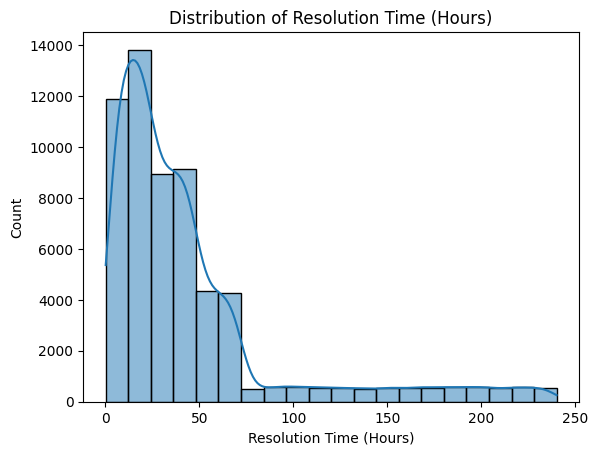

In [9]:
sns.histplot(x= 'resolution_time_hours', data=df, bins=20, kde=True);
plt.title("Distribution of Resolution Time (Hours)");
plt.xlabel("Resolution Time (Hours)");

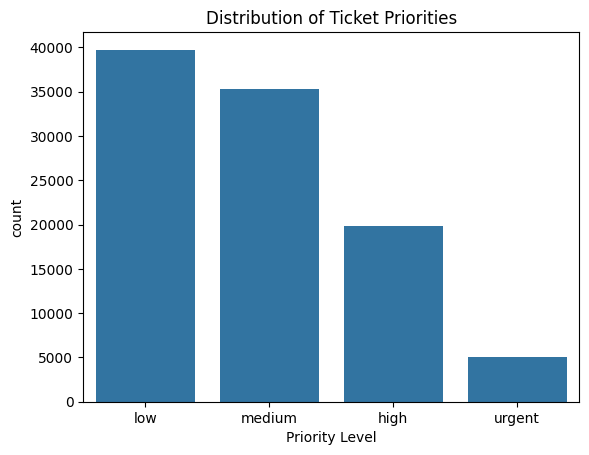

In [10]:
sns.countplot(x='priority',order=df['priority'].value_counts().index, data=df);
plt.title("Distribution of Ticket Priorities");
plt.xlabel("Priority Level");

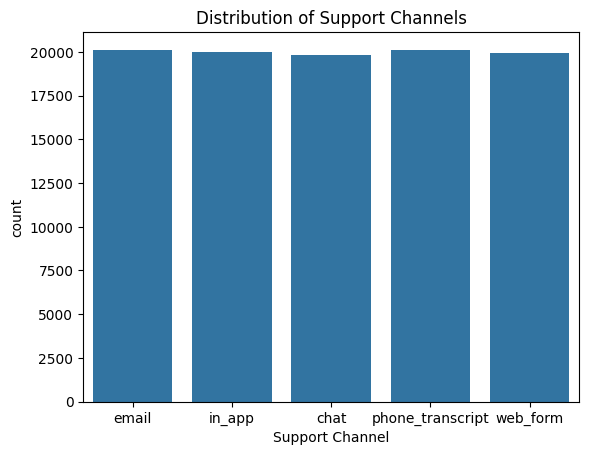

In [11]:
sns.countplot(x= 'channel', data=df);
plt.title("Distribution of Support Channels");
plt.xlabel("Support Channel");

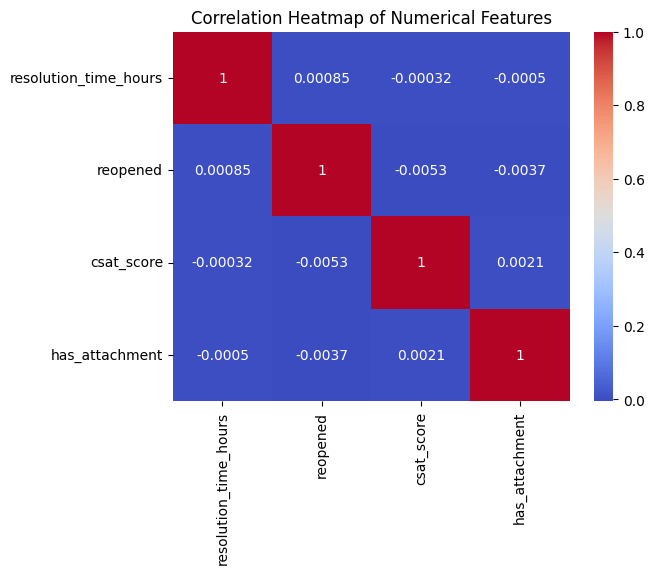

In [12]:
num_data= df.select_dtypes(include=['int64', 'float64'])
corr= num_data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm');
plt.title("Correlation Heatmap of Numerical Features");

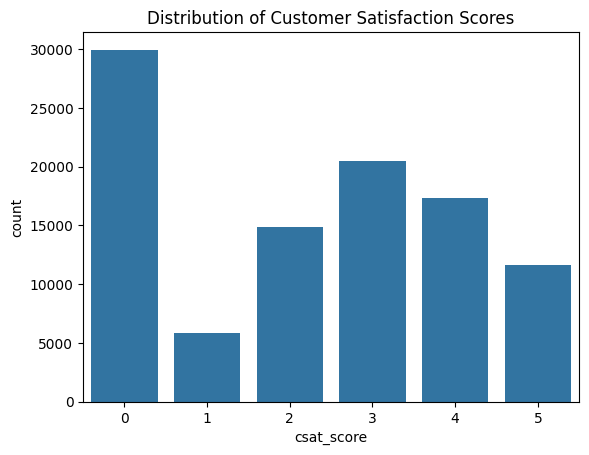

In [13]:
sns.countplot(x= 'csat_score', data=df);
plt.title("Distribution of Customer Satisfaction Scores");

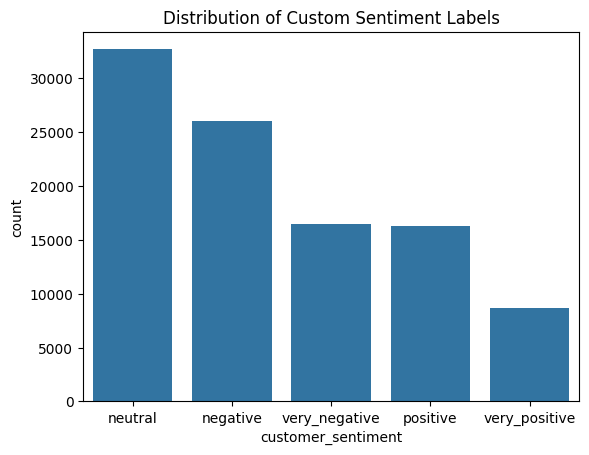

In [14]:
sns.countplot(x= 'customer_sentiment', order=df['customer_sentiment'].value_counts().index, data=df);
plt.title("Distribution of Custom Sentiment Labels");

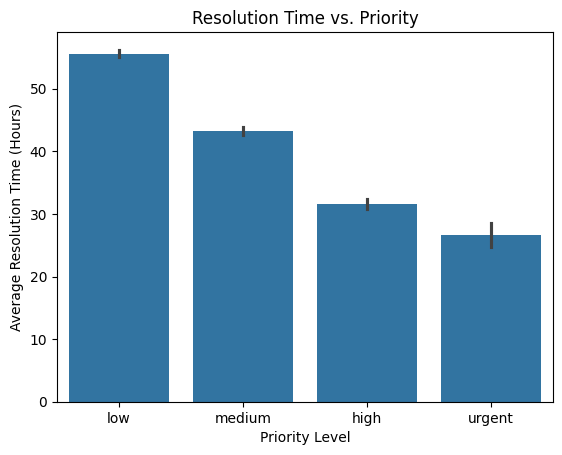

In [15]:
sns.barplot(x='priority', y='resolution_time_hours',order= df['priority'].value_counts().index, data=df);
plt.title("Resolution Time vs. Priority");
plt.xlabel("Priority Level");
plt.ylabel("Average Resolution Time (Hours)");

## EDA Insights
* __Resolution time:__ It is reight-skewed which indicates most tickets are resolved quickly, a long tail indicates that some tickets take a very long time.
* __Priority:__ Majority of tickets have low or medium priority.
* __Channels:__ Customers use all channels of communication equally ~20% each.
* __Heat Map:__ indicates the numerical columns have very low correlation between each other.
* __Customer Satisfaction:__ Sentiment is predominantly neutral or negative. While ~30% of users don't fill the feedback form which results in a zero, and the highest percentage of people who fill it give 3/5.
* __Priority vs. Resloution Time:__ On average the higher the priority of the ticket is the lower its resolution time is.